In [1]:
import random

import numpy as np
import torch


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

In [3]:
import pandas as pd


train_path = "../data/KDDTrain+.txt"
test_path = "../data/KDDTest+.txt"

train_df = pd.read_csv(train_path, names=columns)
test_df = pd.read_csv(test_path, names=columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
print(train_df.info())
print("\nMissing values in train:", train_df.isnull().sum().sum())
print("Missing values in test:", test_df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [5]:
train_df["binary_label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"] = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

print(train_df["binary_label"].value_counts())
print(test_df["binary_label"].value_counts())

binary_label
0    67343
1    58630
Name: count, dtype: int64
binary_label
1    12833
0     9711
Name: count, dtype: int64


In [6]:
dos_attacks = ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop', 'mailbomb',
               'apache2', 'processtable', 'udpstorm']
probe_attacks = ['ipsweep', 'nmap', 'portsweep', 'satan', 'mscan', 'saint']
r2l_attacks = ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy',
               'warezclient', 'warezmaster', 'sendmail', 'named', 'snmpgetattack',
               'snmpguess', 'xlock', 'xsnoop', 'worm']
u2r_attacks = ['buffer_overflow', 'loadmodule', 'perl', 'rootkit', 'httptunnel',
               'ps', 'sqlattack', 'xterm']

def attack_category(label):
    if label == "normal":
        return "normal"
    elif label in dos_attacks:
        return "dos"
    elif label in probe_attacks:
        return "probe"
    elif label in r2l_attacks:
        return "r2l"
    elif label in u2r_attacks:
        return "u2r"
    else:
        return "other"

train_df["attack_category"] = train_df["label"].apply(attack_category)
test_df["attack_category"] = test_df["label"].apply(attack_category)

train_df["attack_category"].value_counts()

attack_category
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

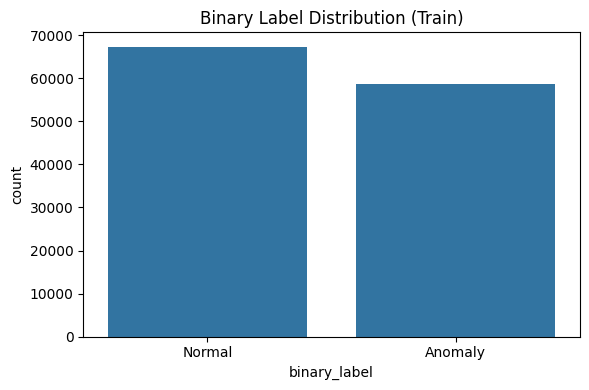

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# EDA: binary label distribution
plt.figure(figsize=(6,4))
sns.countplot(x="binary_label", data=train_df)
plt.title("Binary Label Distribution (Train)")
plt.xticks([0,1], ["Normal", "Anomaly"])
plt.tight_layout()
plt.savefig("../results/figures/binary_distribution_train.png")
plt.show()

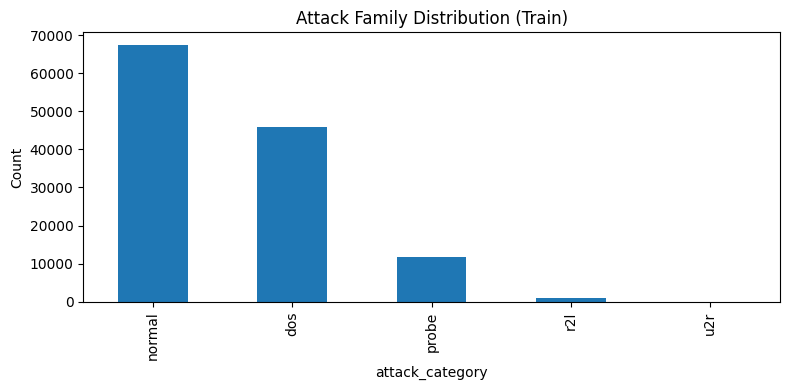

In [8]:
# EDA: attack family distribution
plt.figure(figsize=(8,4))
train_df["attack_category"].value_counts().plot(kind="bar")
plt.title("Attack Family Distribution (Train)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../results/figures/attack_family_distribution.png")
plt.show()

In [9]:
train_df.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.0,0.0,0.0,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.0,44.0,276.0,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.0,0.0,516.0,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.0,0.0,0.0,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.0,0.0,0.0,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.0,0.0,0.0,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.0,0.0,0.0,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.0,0.0,0.0,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.0,0.0,1.0,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.0,0.0,0.0,7.479000e+03


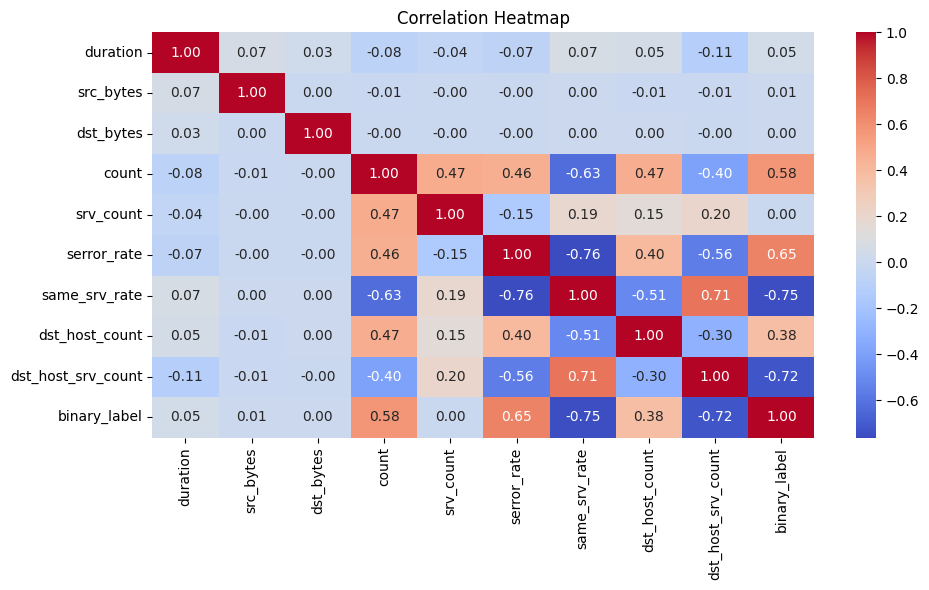

In [10]:
# EDA: correlation heatmap for selected numerical features
selected_cols = [
    "duration", "src_bytes", "dst_bytes", "count", "srv_count",
    "serror_rate", "same_srv_rate", "dst_host_count", "dst_host_srv_count",
    "binary_label"
]

plt.figure(figsize=(10,6))
sns.heatmap(train_df[selected_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../results/figures/correlation_heatmap.png")
plt.show()

In [11]:
# Feature selection
categorical_cols = ["protocol_type", "service", "flag"]
drop_cols = ["label", "difficulty", "attack_category", "binary_label"]

feature_cols = [c for c in train_df.columns if c not in drop_cols]
numerical_cols = [c for c in feature_cols if c not in categorical_cols]

print("Total features:", len(feature_cols))
print("Categorical:", categorical_cols)
print("Numerical count:", len(numerical_cols))

Total features: 41
Categorical: ['protocol_type', 'service', 'flag']
Numerical count: 38


In [12]:
# Encode categorical columns and scale numerical columns
from sklearn.preprocessing import LabelEncoder, StandardScaler


full_df = pd.concat([train_df[feature_cols], test_df[feature_cols]], axis=0).copy()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    full_df[col] = le.fit_transform(full_df[col])
    label_encoders[col] = le

scaler = StandardScaler()
full_df[numerical_cols] = scaler.fit_transform(full_df[numerical_cols])

X_train = full_df.iloc[:len(train_df)].reset_index(drop=True)
X_test = full_df.iloc[len(train_df):].reset_index(drop=True)

y_train = train_df["binary_label"].values
y_test = test_df["binary_label"].values

print(X_train.shape, X_test.shape)

(125973, 41) (22544, 41)


In [13]:
import joblib


joblib.dump(label_encoders, "../results/models/label_encoders.pkl")
joblib.dump(scaler, "../results/models/scaler.pkl")

['../results/models/scaler.pkl']

In [14]:
from sklearn.model_selection import train_test_split


X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_np, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(X_tr.shape, X_val.shape, X_test_np.shape)

(100778, 41) (25195, 41) (22544, 41)


In [15]:
from torch.utils.data import Dataset


# Pytorch dataset
class NSLKDDDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [16]:
from torch.utils.data import DataLoader


train_dataset = NSLKDDDataset(X_tr, y_tr)
val_dataset = NSLKDDDataset(X_val, y_val)
test_dataset = NSLKDDDataset(X_test_np, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)


def evaluate_predictions(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

In [18]:
from sklearn.metrics import confusion_matrix


def plot_confusion(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

In [19]:
from sklearn.metrics import roc_curve


def plot_roc_curve(y_true, y_prob, title, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

In [25]:
import os
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_model_path = "../results/models/random_forest.pkl"

if os.path.exists(rf_model_path):
    rf_model = joblib.load(rf_model_path)
    print("Loaded saved Random Forest model.")
else:
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_tr, y_tr)
    joblib.dump(rf_model, rf_model_path)
    print("Trained and saved Random Forest model.")

Loaded saved Random Forest model.


In [26]:
# Evaluate Random Forest
rf_pred = rf_model.predict(X_test_np)
rf_prob = rf_model.predict_proba(X_test_np)[:, 1]

rf_metrics = evaluate_predictions(y_test, rf_pred, rf_prob)
rf_metrics

{'accuracy': 0.7704045422285308,
 'precision': 0.9661512236697918,
 'recall': 0.6183277487726954,
 'f1': 0.7540625296968545,
 'roc_auc': 0.9635925973563596}

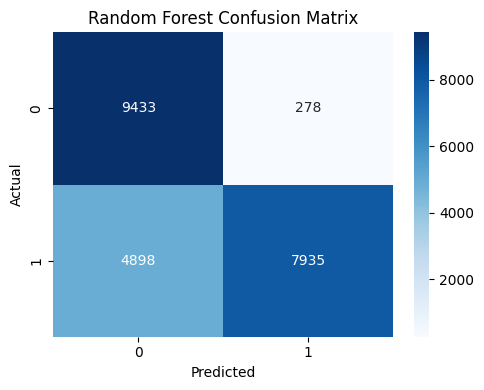

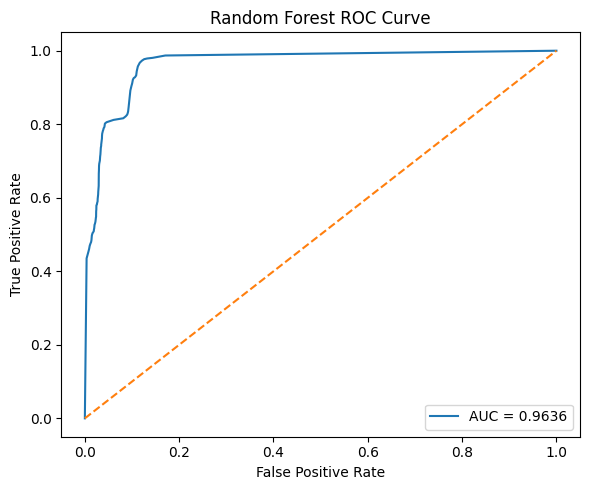

              precision    recall  f1-score   support

      Normal       0.66      0.97      0.78      9711
     Anomaly       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.77     22544



In [23]:
from sklearn.metrics import classification_report


# Save Random Forest metrics and plots
joblib.dump(rf_metrics, "../results/metrics/random_forest_metrics.pkl")

plot_confusion(
    y_test, rf_pred,
    "Random Forest Confusion Matrix",
    "../results/figures/rf_confusion_matrix.png"
)

plot_roc_curve(
    y_test, rf_prob,
    "Random Forest ROC Curve",
    "../results/figures/rf_roc_curve.png"
)

print(classification_report(y_test, rf_pred, target_names=["Normal", "Anomaly"]))

In [27]:
import torch.nn as nn


# Transformer model definition
class FTTransformerClassifier(nn.Module):
    def __init__(self, input_dim, embed_dim=64, num_heads=4,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.feature_embedding = nn.Linear(1, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                 num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim * embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = x.unsqueeze(-1)           # [B, F, 1]
        x = self.feature_embedding(x) # [B, F, E]
        x = self.transformer(x)        # [B, F, E]
        return self.classifier(x).squeeze(1)  # [B]

In [28]:
import torch.optim as optim


# Transformer training function
def train_torch_binary_model(model, train_loader, val_loader,
                              epochs=30, lr=1e-3, patience=5):
    criterion  = nn.BCEWithLogitsLoss()
    optimizer  = optim.Adam(model.parameters(), lr=lr)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    history         = {"train_loss": [], "val_loss": []}
    best_val_loss   = float("inf")
    best_state      = None
    patience_counter = 0

    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_losses.append(criterion(model(X_batch), y_batch).item())

        avg_train = float(np.mean(train_losses))
        avg_val   = float(np.mean(val_losses))
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)

        scheduler.step(avg_val)
        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

        if avg_val < best_val_loss:
            best_val_loss    = avg_val
            best_state       = {k: v.cpu().clone()
                                 for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} "
                      f"(no improvement for {patience} epochs).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [32]:
# Transformer test evaluation function
def evaluate_torch_binary_model(model, data_loader):
    model.eval()
    preds, probs, true = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            batch_probs = torch.sigmoid(logits).cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)

            probs.extend(batch_probs)
            preds.extend(batch_preds)
            true.extend(y_batch.numpy())

    true = np.array(true)
    preds = np.array(preds)
    probs = np.array(probs)

    metrics = evaluate_predictions(true, preds, probs)
    return metrics, true, preds, probs

In [33]:
# Train or load Transformer
transformer_model_path   = "../results/models/transformer_model.pth"
transformer_history_path = "../results/metrics/transformer_history.pkl"

transformer_model = FTTransformerClassifier(input_dim=X_tr.shape[1]).to(device)

if os.path.exists(transformer_model_path):
    transformer_model.load_state_dict(
        torch.load(transformer_model_path, map_location=device)
    )
    print("Loaded saved Transformer model.")
    transformer_history = (joblib.load(transformer_history_path)
                           if os.path.exists(transformer_history_path) else None)
else:
    transformer_history = train_torch_binary_model(
        transformer_model, train_loader, val_loader,
        epochs=30, lr=1e-3, patience=5
    )
    torch.save(transformer_model.state_dict(), transformer_model_path)
    joblib.dump(transformer_history, transformer_history_path)
    print("Trained and saved Transformer model.")


Loaded saved Transformer model.


In [34]:
# Evaluate Transformer
transformer_metrics, y_true_t, y_pred_t, y_prob_t = evaluate_torch_binary_model(
    transformer_model, test_loader
)

transformer_metrics

{'accuracy': 0.77541696238467,
 'precision': 0.9732034104750305,
 'recall': 0.6226135743785552,
 'f1': 0.7593974243216272,
 'roc_auc': 0.9489457188377235}

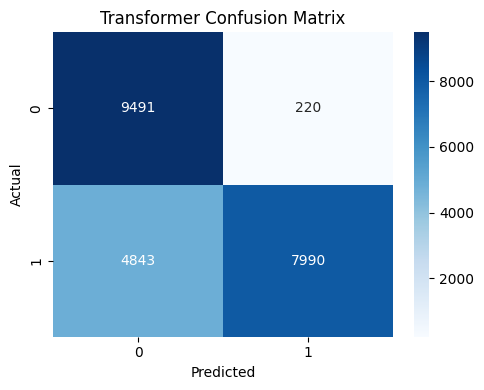

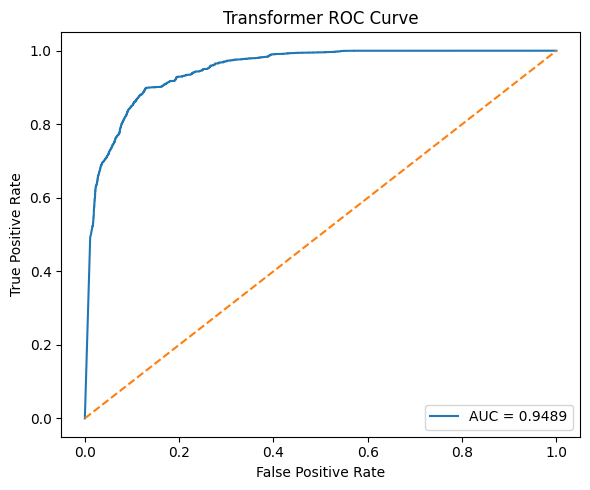

              precision    recall  f1-score   support

      Normal       0.66      0.98      0.79      9711
     Anomaly       0.97      0.62      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.77     22544
weighted avg       0.84      0.78      0.77     22544



In [32]:
# Save Transformer metrics and plots
joblib.dump(transformer_metrics, "../results/metrics/transformer_metrics.pkl")

plot_confusion(
    y_true_t, y_pred_t,
    "Transformer Confusion Matrix",
    "../results/figures/transformer_confusion_matrix.png"
)

plot_roc_curve(
    y_true_t, y_prob_t,
    "Transformer ROC Curve",
    "../results/figures/transformer_roc_curve.png"
)

print(classification_report(y_true_t, y_pred_t, target_names=["Normal", "Anomaly"]))

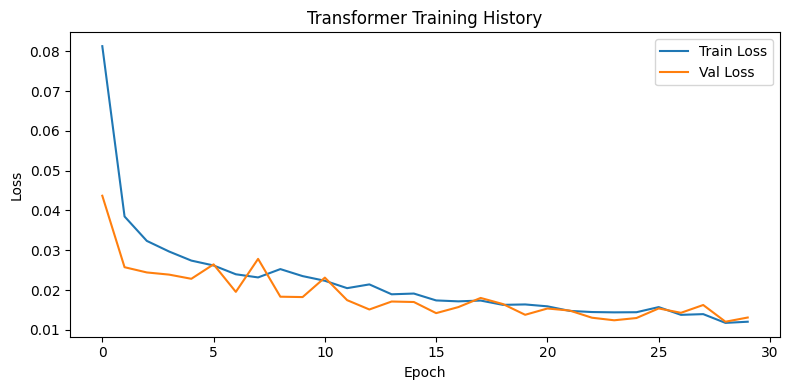

In [33]:
# Plot Transformer training history
if transformer_history is not None:
    plt.figure(figsize=(8,4))
    plt.plot(transformer_history["train_loss"], label="Train Loss")
    plt.plot(transformer_history["val_loss"], label="Val Loss")
    plt.title("Transformer Training History")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig("../results/figures/transformer_training_history.png")
    plt.show()

In [35]:
from sklearn.neighbors import kneighbors_graph
from torch_geometric.data import Data


# # Build graph for GNN
X_graph_all = np.vstack([X_train_np, X_test_np])
y_graph_all = np.concatenate([y_train, y_test])

n_train_nodes = len(X_train_np)
n_test_nodes  = len(X_test_np)

print("Building kNN graph (this may take ~1–2 min on CPU)…")
adj_sparse = kneighbors_graph(
    X_graph_all, n_neighbors=10,
    mode="connectivity", include_self=False
)
edge_index = np.array(adj_sparse.nonzero())

x_tensor = torch.tensor(X_graph_all, dtype=torch.float32)
y_tensor = torch.tensor(y_graph_all, dtype=torch.long)
edge_index_tensor = torch.tensor(edge_index,  dtype=torch.long)

graph_data = Data(x=x_tensor, edge_index=edge_index_tensor, y=y_tensor)
print(graph_data)

c:\Users\user\Desktop\NetGuard\venv310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\user\Desktop\NetGuard\venv310\lib\site-packages\torch_geometric\llm\utils\backend_utils.py:26: DeprecationWarning: `torch_geometric.distributed` has been deprecated since 2.7.0 and will no longer be maintained. For distributed training, refer to our tutorials on distributed training at https://pytorch-geometric.readthedocs.io/en/latest/tutorial/distributed.html or cuGraph examples at https://github.com/rapidsai/cugraph-gnn/tree/main/python/cugraph-pyg/cugraph_pyg/examples
  from torch_geometric.distributed import (


Building kNN graph (this may take ~1–2 min on CPU)…
Data(x=[148517, 41], edge_index=[2, 1485170], y=[148517])


In [36]:
# Train/val/test masks for graph
num_total    = graph_data.num_nodes
train_indices = np.arange(n_train_nodes)
test_indices  = np.arange(n_train_nodes, n_train_nodes + n_test_nodes)

train_idx, val_idx = train_test_split(
    train_indices, test_size=0.2, random_state=42, stratify=y_train
)

train_mask = torch.zeros(num_total, dtype=torch.bool)
val_mask = torch.zeros(num_total, dtype=torch.bool)
test_mask = torch.zeros(num_total, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_indices] = True

graph_data.train_mask = train_mask
graph_data.val_mask = val_mask
graph_data.test_mask = test_mask

print(f"Train: {train_mask.sum()} | Val: {val_mask.sum()} | Test: {test_mask.sum()}")

Train: 100778 | Val: 25195 | Test: 22544


In [37]:
from torch_geometric.nn import GCNConv


# GNN model definition
class GCNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = torch.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = torch.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        return self.classifier(x)

In [38]:
import os


# Train or load GNN
gnn_model_path   = "../results/models/gnn_model.pth"
gnn_history_path = "../results/metrics/gnn_history.pkl"

gnn_model  = GCNClassifier(input_dim=X_graph_all.shape[1]).to(device)
graph_data = graph_data.to(device)

if os.path.exists(gnn_model_path):
    gnn_model.load_state_dict(torch.load(gnn_model_path, map_location=device))
    print("Loaded saved GNN model.")
    gnn_history = (joblib.load(gnn_history_path)
                   if os.path.exists(gnn_history_path) else None)
else:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(gnn_model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4
    )

    gnn_history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0
    EPOCHS, PATIENCE = 50, 7

    for epoch in range(EPOCHS):
        gnn_model.train()
        optimizer.zero_grad()
        out  = gnn_model(graph_data)
        loss = criterion(out[graph_data.train_mask],
                         graph_data.y[graph_data.train_mask])
        loss.backward()
        optimizer.step()

        gnn_model.eval()
        with torch.no_grad():
            val_out  = gnn_model(graph_data)
            val_loss = criterion(val_out[graph_data.val_mask],
                                 graph_data.y[graph_data.val_mask])

        gnn_history["train_loss"].append(loss.item())
        gnn_history["val_loss"].append(val_loss.item())
        scheduler.step(val_loss.item())

        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

        if val_loss.item() < best_val_loss:
            best_val_loss    = val_loss.item()
            best_state       = {k: v.cpu().clone()
                                 for k, v in gnn_model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}.")
                break

    if best_state is not None:
        gnn_model.load_state_dict(best_state)

    torch.save(gnn_model.state_dict(), gnn_model_path)
    joblib.dump(gnn_history, gnn_history_path)
    print("Trained and saved GNN model.")

Loaded saved GNN model.


In [39]:
# Evaluate GNN
gnn_model.eval()
with torch.no_grad():
    out = gnn_model(graph_data)
    probs_all = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
    preds_all = out.argmax(dim=1).cpu().numpy()
    true_all = graph_data.y.cpu().numpy()

test_mask_np = graph_data.test_mask.cpu().numpy()

y_true_g = true_all[test_mask_np]
y_pred_g = preds_all[test_mask_np]
y_prob_g = probs_all[test_mask_np]

gnn_metrics = evaluate_predictions(y_true_g, y_pred_g, y_prob_g)
gnn_metrics

{'accuracy': 0.7577182398864443,
 'precision': 0.9304987735077678,
 'recall': 0.6207433959323618,
 'f1': 0.744694774235767,
 'roc_auc': 0.8913742031325744}

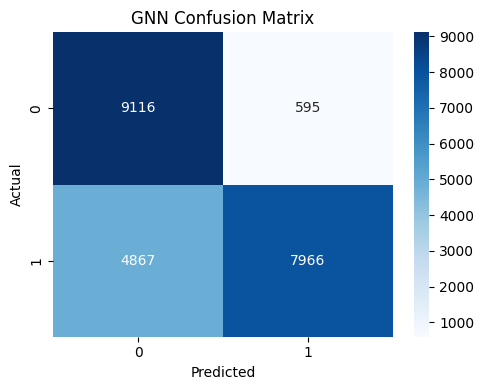

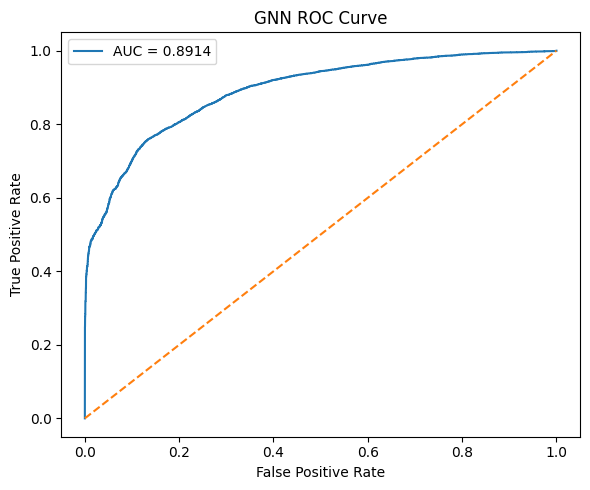

              precision    recall  f1-score   support

      Normal       0.65      0.94      0.77      9711
     Anomaly       0.93      0.62      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.79      0.78      0.76     22544
weighted avg       0.81      0.76      0.76     22544



In [42]:
from sklearn.metrics import classification_report


# Save GNN metrics and plots
joblib.dump(gnn_metrics, "../results/metrics/gnn_metrics.pkl")

plot_confusion(
    y_true_g, y_pred_g,
    "GNN Confusion Matrix",
    "../results/figures/gnn_confusion_matrix.png"
)

plot_roc_curve(
    y_true_g, y_prob_g,
    "GNN ROC Curve",
    "../results/figures/gnn_roc_curve.png"
)

print(classification_report(y_true_g, y_pred_g, target_names=["Normal", "Anomaly"]))

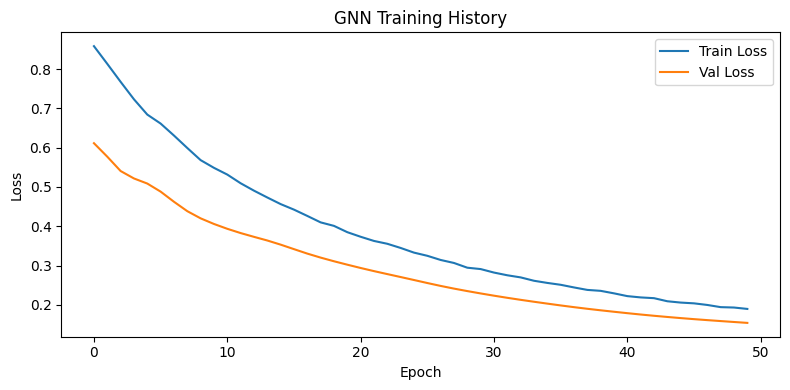

In [43]:
# Plot GNN training history
if gnn_history is not None:
    plt.figure(figsize=(8,4))
    plt.plot(gnn_history["train_loss"], label="Train Loss")
    plt.plot(gnn_history["val_loss"], label="Val Loss")
    plt.title("GNN Training History")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig("../results/figures/gnn_training_history.png")
    plt.show()

In [20]:
import os
from tabpfn import TabPFNClassifier

TABPFN_MAX = 1000
sub_idx, _ = train_test_split(
    np.arange(len(X_tr)), train_size=TABPFN_MAX,
    random_state=42, stratify=y_tr
)
X_tr_sub = X_tr[sub_idx]
y_tr_sub = y_tr[sub_idx]

print(f"TabPFN training on {TABPFN_MAX} samples ({TABPFN_MAX/len(X_tr)*100:.2f}% of training data)")
print(f"Class distribution: {np.bincount(y_tr_sub)}")

tabpfn_model_path = "../results/models/tabpfn_model.pkl"

if os.path.exists(tabpfn_model_path):
    tabpfn_model = joblib.load(tabpfn_model_path)
    print("Loaded saved TabPFN model.")
else:
    tabpfn_model = TabPFNClassifier(
        device="cuda" if torch.cuda.is_available() else "cpu",
        N_ensemble_configurations=16
    )
    tabpfn_model.fit(X_tr_sub, y_tr_sub)
    joblib.dump(tabpfn_model, tabpfn_model_path)

TabPFN training on 1000 samples (0.99% of training data)
Class distribution: [535 465]


In [22]:
from sklearn.metrics import classification_report

def tabpfn_predict_in_batches(model, X, batch_size=256):
    probs = []

    for i in range(0, len(X), batch_size):
        X_batch = X[i:i+batch_size]
        prob_batch = model.predict_proba(X_batch)[:, 1]
        probs.extend(prob_batch)

    return np.array(probs)

tabpfn_prob = tabpfn_predict_in_batches(tabpfn_model, X_test_np, batch_size=256)
tabpfn_pred = (tabpfn_prob > 0.5).astype(int)

tabpfn_metrics = evaluate_predictions(y_test, tabpfn_pred, tabpfn_prob)
joblib.dump(tabpfn_metrics, "../results/metrics/tabpfn_metrics.pkl")

print(tabpfn_metrics)
print()
print(classification_report(y_test, tabpfn_pred, target_names=["Normal", "Anomaly"]))

c:\Users\user\Desktop\NetGuard\venv310\lib\site-packages\tabpfn\scripts\transformer_prediction_interface.py:530: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=fp16_inference):
c:\Users\user\Desktop\NetGuard\venv310\lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
c:\Users\user\Desktop\NetGuard\venv310\lib\site-packages\tabpfn\scripts\transformer_prediction_interface.py:530: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', a

{'accuracy': 0.7890347764371894, 'precision': 0.9655331412103746, 'recall': 0.6526922777214993, 'f1': 0.7788729774967454, 'roc_auc': 0.958566669317097}

              precision    recall  f1-score   support

      Normal       0.68      0.97      0.80      9711
     Anomaly       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



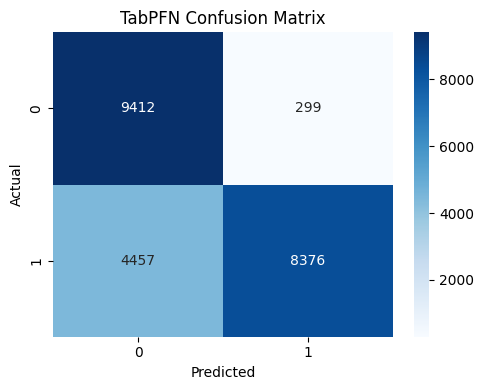

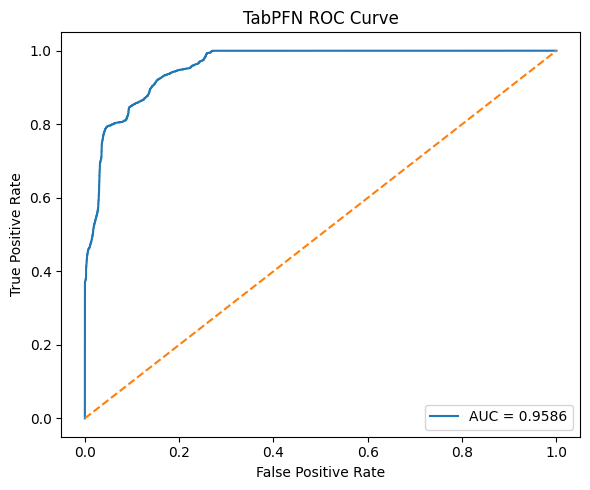

In [23]:
plot_confusion(
    y_test, tabpfn_pred,
    "TabPFN Confusion Matrix",
    "../results/figures/tabpfn_confusion_matrix.png"
)

plot_roc_curve(
    y_test, tabpfn_prob,
    "TabPFN ROC Curve",
    "../results/figures/tabpfn_roc_curve.png"
)

In [40]:
all_metrics = {
    "Random Forest"  : rf_metrics,
    "Transformer"    : transformer_metrics,
    "GNN"            : gnn_metrics,
    "TabPFN (1 000)" : tabpfn_metrics,
}

comparison_df = pd.DataFrame(all_metrics).T.round(4)
comparison_df.index.name = "Model"
print(comparison_df.to_string())
comparison_df

                accuracy  precision  recall      f1  roc_auc
Model                                                       
Random Forest     0.7704     0.9662  0.6183  0.7541   0.9636
Transformer       0.7754     0.9732  0.6226  0.7594   0.9489
GNN               0.7577     0.9305  0.6207  0.7447   0.8914
TabPFN (1 000)    0.7890     0.9655  0.6527  0.7789   0.9586


,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Random Forest,0.7704,0.9662,0.6183,0.7541,0.9636
Transformer,0.7754,0.9732,0.6226,0.7594,0.9489
GNN,0.7577,0.9305,0.6207,0.7447,0.8914
TabPFN (1 000),0.7890,0.9655,0.6527,0.7789,0.9586


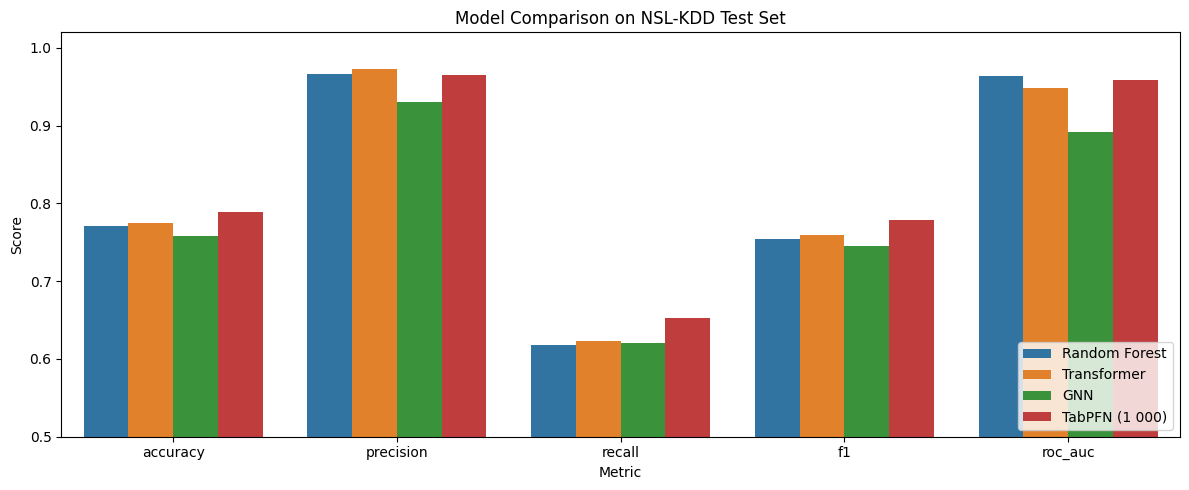

In [41]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]
plot_df = comparison_df[metrics_to_plot].reset_index().melt(
    id_vars="Model", var_name="Metric", value_name="Score"
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.ylim(0.5, 1.02)
plt.title("Model Comparison on NSL-KDD Test Set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/figures/model_comparison.png")
plt.show()